# Optimizacion de hiperparametros con Optuna (TPE) - metrica: Brier score

Partiendo de los datos preprocesados y filtrados en `06_clean_preprocessing_and_filtering_model.ipynb`,
realizamos optimizacion automatica de hiperparametros para **LightGBM**, **XGBoost** y
**CatBoost** usando el **Tree-structured Parzen Estimator (TPE)** de Optuna.

**Metrica optimizada: Brier score**

El Brier score es el MSE entre la probabilidad predicha y la etiqueta real (0/1): $\frac{1}{N}\sum_i (y_i - \hat p_i)^2$.
A diferencia de AUC, que solo mide el **ranking** entre clases, el Brier score **penaliza tambien la calibracion**
de las probabilidades. Es una metrica estricta de calidad probabilistica, adecuada cuando las probabilidades
se usan directamente (ej. calculo de perdidas esperadas).

Es una **loss** (menor es mejor), asi que los studies de Optuna van con `direction='minimize'`.

**Nota tecnica:** mantenemos `class_weight='balanced'` / `scale_pos_weight` / `auto_class_weights='Balanced'`
como en los notebooks anteriores. Estos pesos inflan las probabilidades hacia la clase minoritaria, lo que
degrada el Brier absoluto. Si se quisiera un Brier optimo, lo natural seria quitar esos pesos y calibrar
despues (ver notebook 10 de calibracion). Aqui priorizamos mantener el setup comparable.

**Metricas de referencia (sobre test) de notebooks anteriores:**

| Modelo | Accuracy | AUC-ROC | Recall (Default) | F1 (Default) |
|---|---|---|---|---|
| Baseline FICO | 0.72 | 0.592 | 0.24 | 0.25 |
| Random Forest (06_) | 0.80 | 0.683 | 0.02 | 0.04 |
| CatBoost (07_, sin tuning) | 0.67 | 0.708 | 0.62 | 0.43 |
| LightGBM (07_, sin tuning) | 0.67 | 0.706 | 0.61 | 0.43 |
| XGBoost (07_, sin tuning) | 0.67 | 0.704 | 0.61 | 0.42 |

## Por que TPE y no Grid/Random Search?

**Grid Search** prueba todas las combinaciones posibles: explota combinatoria mala (con 5 parametros y 5 valores cada uno son 3125 trials). **Random Search** muestrea uniformemente el espacio: mejor que grid pero no aprende de las evaluaciones anteriores.

**TPE (Tree-structured Parzen Estimator)** es un metodo Bayesiano basado en Sequential Model-Based Optimization (SMBO). Su idea central:

1. Despues de unos cuantos trials aleatorios (warmup), divide los trials en **buenos** (mejor X% por la metrica) y **malos** (el resto).
2. Ajusta dos **densidades de probabilidad** (Parzen windows / KDE):
   - `l(x)` = densidad de hiperparametros en trials buenos
   - `g(x)` = densidad de hiperparametros en trials malos
3. Para elegir el siguiente set de hiperparametros, maximiza el ratio `l(x) / g(x)`: busca puntos **probables bajo los buenos** y **improbables bajo los malos**.

Ventajas frente a Grid/Random:
- Aprende de los trials anteriores: enfoca el muestreo en zonas prometedoras.
- Maneja **espacios condicionales** (tree-structured): ej. si `boosting_type='dart'`, entonces `drop_rate` es activo. Por eso se llama *tree-structured*.
- Escalable a decenas de hiperparametros sin sufrir la maldicion de la dimensionalidad tanto como Grid.

Ademas usamos **MedianPruner**: corta trials cuya curva intermedia de validacion (por ronda de boosting) esta por debajo de la mediana historica en ese punto. Permite hacer mas trials en el mismo tiempo.

## PASO 1: Carga de datos preprocesados y filtrados

Partimos del pickle generado al final del notebook `06_clean_preprocessing_and_filtering_model.ipynb` (train/test ya con preprocesamiento y feature filtering aplicados).

In [1]:
import pickle
import numpy as np

with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_filtered = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_filtered = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)

y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# scale_pos_weight para XGBoost (LightGBM puede usar class_weight='balanced')
n_negative = np.sum(~y_train_flat)
n_positive = np.sum(y_train_flat)
scale_pos_weight = n_negative / n_positive

print(f"Train: {X_train_filtered.shape}  |  Test: {X_test_filtered.shape}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Train: (80000, 163)  |  Test: (20000, 163)
scale_pos_weight = 3.93


In [2]:
# Split interno train/val para la optimizacion con TPE.
# El test queda reservado SOLO para la evaluacion final de los modelos tuneados.
# Si usaramos test en la optimizacion, las metricas finales estarian sesgadas (leakage).
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_filtered, y_train_flat,
    test_size=0.2, random_state=42, stratify=y_train_flat
)
print(f"Train interno: {X_tr.shape}  |  Val interno: {X_val.shape}")

Train interno: (64000, 163)  |  Val interno: (16000, 163)


In [3]:
# Funcion comun de evaluacion final sobre test (adaptada del notebook 07).
# Anadimos Brier score como metrica, ademas de AUC, precision, recall y F1.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, brier_score_loss
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name, results_dict):
    class_pred = model.predict(X_test)
    prob_pred = model.predict_proba(X_test)[:, 1]
    results_dict[model_name] = {
        'Accuracy': accuracy_score(y_test, class_pred),
        'Precision': precision_score(y_test, class_pred),
        'Recall': recall_score(y_test, class_pred),
        'F1-Score': f1_score(y_test, class_pred),
        'AUC-ROC': roc_auc_score(y_test, prob_pred),
        'Brier': brier_score_loss(y_test, prob_pred),
        'prob_pred': prob_pred, 'class_pred': class_pred
    }
    print(f"\n{'='*60}\n  {model_name}\n{'='*60}")
    print(classification_report(y_test, class_pred, target_names=["Fully Paid", "Default"]))
    print(f"  AUC-ROC: {results_dict[model_name]['AUC-ROC']:.4f}")
    print(f"  Brier:   {results_dict[model_name]['Brier']:.4f}")
    return results_dict

results = {}

## PASO 2: Optimizacion de LightGBM con TPE (Brier score)

Definimos un **objective function** que Optuna llamara repetidamente. En cada llamada:
1. Optuna propone un set de hiperparametros mediante `trial.suggest_*`.
2. Entrenamos el modelo con esos hiperparametros en `X_tr, y_tr`.
3. Devolvemos el Brier score en val. Optuna lo usa para alimentar al TPE.

LightGBM **no expone el Brier score como metrica string**, asi que definimos una funcion
custom que devuelve `('brier', valor, is_higher_better=False)`. Esta funcion se pasa como
`eval_metric` y el `LightGBMPruningCallback` la monitorea con `metric='brier'`.

### Espacio de busqueda para LightGBM

| Hiperparametro | Rango | Tipo | Justificacion |
|---|---|---|---|
| `learning_rate` | 0.005 - 0.3 | log-uniform | Rates mas bajos generalizan mejor pero necesitan mas iter. Log-uniform es correcto para rates. |
| `num_leaves` | 15 - 255 | int | En LightGBM es el parametro clave para la complejidad (leaf-wise). |
| `max_depth` | 3 - 12 | int | Limite duro a la profundidad; combinado con num_leaves da control fino. |
| `min_child_samples` | 5 - 100 | int | Minimo de muestras por hoja: regulariza contra memorizar ruido. |
| `subsample` | 0.5 - 1.0 | uniform | Bagging de filas (stochastic gradient boosting). |
| `colsample_bytree` | 0.5 - 1.0 | uniform | Bagging de columnas: diversidad entre arboles. |
| `reg_alpha` | 1e-8 - 10 | log-uniform | Regularizacion L1 sobre hojas. Log porque varia ordenes de magnitud. |
| `reg_lambda` | 1e-8 - 10 | log-uniform | Regularizacion L2 sobre hojas. |
| `min_split_gain` | 0 - 0.5 | uniform | Ganancia minima para hacer un split (poda implicita). |

In [4]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.integration import LightGBMPruningCallback
from lightgbm import LGBMClassifier
import lightgbm as lgb
from scipy.special import expit

# Eval metric custom para LightGBM: el Brier score no existe como string.
# Signature esperada por LightGBM: (y_true, y_pred) -> (nombre, valor, is_higher_better).
# En el API sklearn de LightGBM, y_pred puede llegar como probabilidad o como raw score
# dependiendo de la version; aplicamos sigmoid solo si los valores estan fuera de [0, 1].
def brier_eval_lgbm(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    if y_pred.min() < 0.0 or y_pred.max() > 1.0:
        y_pred = expit(y_pred)
    brier = float(np.mean((y_true.astype(float) - y_pred) ** 2))
    return 'brier', brier, False   # False = lower is better

def objective_lgbm(trial: optuna.Trial) -> float:
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = LGBMClassifier(**params)

    # Pruning basado en 'brier' (nombre de la eval custom)
    pruning_cb = LightGBMPruningCallback(trial, metric='brier', valid_name='valid_0')

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric=brier_eval_lgbm,
        callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb]
    )

    prob_val = model.predict_proba(X_val)[:, 1]
    return brier_score_loss(y_val, prob_val)

In [5]:
# Creamos el study con:
# - TPESampler: el sampler bayesiano (10 trials aleatorios de warmup, luego TPE)
# - MedianPruner: corta trials malos en cuanto su Brier intermedio esta sobre la mediana
# - direction='minimize': Brier es una loss, menor es mejor
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = TPESampler(
    n_startup_trials=10,    # trials aleatorios antes de activar TPE
    multivariate=True,      # modela dependencias entre hiperparametros
    seed=42,
)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=50)

study_lgbm = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='lightgbm_tpe_brier',
)

study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nMejor Brier en val: {study_lgbm.best_value:.4f}")
print(f"Mejores hiperparametros:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor Brier en val: 0.1607
Mejores hiperparametros:
  learning_rate: 0.02402814382700521
  num_leaves: 250
  max_depth: 11
  min_child_samples: 54
  subsample: 0.5139288683029327
  colsample_bytree: 0.889326943834392
  reg_alpha: 4.790890584273112e-08
  reg_lambda: 0.0050578156072574165
  min_split_gain: 0.07715216982042312


In [6]:
# Resumen del study: cuantos trials completados, pruned, etc.
states = [t.state.name for t in study_lgbm.trials]
from collections import Counter
print("Estados de los trials:", Counter(states))
print(f"Total trials: {len(study_lgbm.trials)}")

Estados de los trials: Counter({'COMPLETE': 31, 'PRUNED': 19})
Total trials: 50


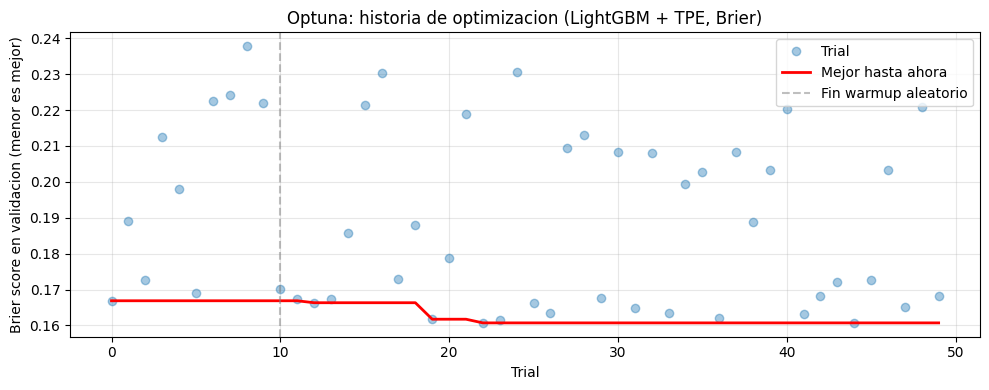

In [7]:
# Historia de optimizacion: como baja el mejor Brier a medida que avanzan los trials.
# Con minimizacion la linea "mejor hasta ahora" baja escalonadamente (TPE enfoca en zonas buenas).
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_lgbm.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Brier score en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (LightGBM + TPE, Brier)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

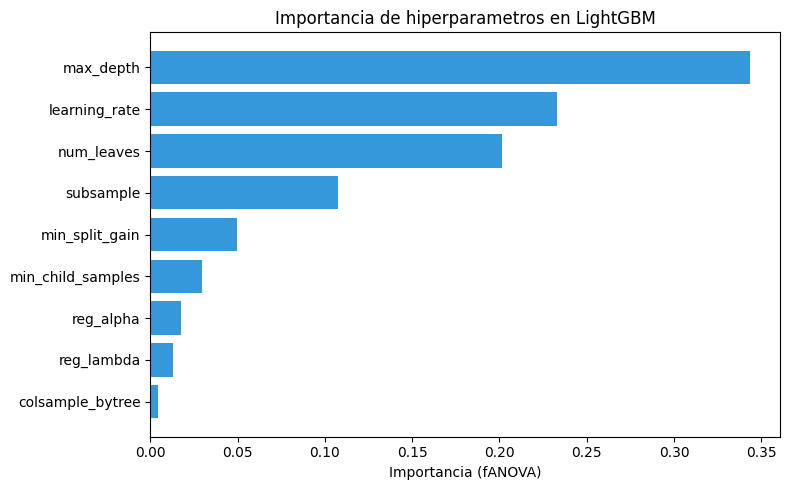

Ranking de importancia:
  max_depth                 0.344
  learning_rate             0.233
  num_leaves                0.202
  subsample                 0.108
  min_split_gain            0.050
  min_child_samples         0.030
  reg_alpha                 0.017
  reg_lambda                0.013
  colsample_bytree          0.005


In [8]:
# Importancia de hiperparametros segun Optuna (funcional ANOVA):
# que parametros explican mas la variabilidad del AUC entre trials?
importances = optuna.importance.get_param_importances(study_lgbm)

fig, ax = plt.subplots(figsize=(8, 5))
params_sorted = list(importances.keys())[::-1]
values_sorted = [importances[p] for p in params_sorted]
ax.barh(params_sorted, values_sorted, color='#3498db')
ax.set_xlabel('Importancia (fANOVA)')
ax.set_title('Importancia de hiperparametros en LightGBM')
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for p, v in importances.items():
    print(f"  {p:25s} {v:.3f}")

In [9]:
# Entrenamos el LightGBM final con los mejores hiperparametros y early stopping por Brier.
best_params_lgbm = dict(study_lgbm.best_params)
best_params_lgbm.update({
    'n_estimators': 2000,
    'subsample_freq': 1,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
})

lgbm_best = LGBMClassifier(**best_params_lgbm)
lgbm_best.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric=brier_eval_lgbm,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
print(f"Iteraciones usadas tras early stopping: {lgbm_best.best_iteration_}")

results = evaluate_model(lgbm_best, X_test_filtered, y_test_flat, 'LightGBM + TPE', results)

Iteraciones usadas tras early stopping: 1151



  LightGBM + TPE
              precision    recall  f1-score   support

  Fully Paid       0.83      0.91      0.87     16003
     Default       0.41      0.26      0.32      3997

    accuracy                           0.78     20000
   macro avg       0.62      0.58      0.59     20000
weighted avg       0.75      0.78      0.76     20000

  AUC-ROC: 0.6874
  Brier:   0.1580


## PASO 3: Optimizacion de XGBoost con TPE (Brier score)

Mismo esquema con metrica custom. En XGBoost (API sklearn), una `eval_metric` callable
recibe `(y_true, y_pred)` y devuelve `(nombre, valor)`. Para XGBoost `y_pred` ya viene
como probabilidad en binary classification. El `XGBoostPruningCallback` monitorea
`'validation_0-brier'`.

In [10]:
from xgboost import XGBClassifier
from optuna.integration import XGBoostPruningCallback

# En XGBoost (API sklearn), eval_metric callable devuelve un float (no tupla).
# El nombre de la metrica es el __name__ de la funcion: aqui 'brier' -> callback ve 'validation_0-brier'.
# Para XGBoost binario, y_pred ya viene como probabilidad; la salvaguarda con expit es defensiva.
def brier(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    if y_pred.min() < 0.0 or y_pred.max() > 1.0:
        y_pred = expit(y_pred)
    return float(np.mean((y_true.astype(float) - y_pred) ** 2))

def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-2, 20, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': brier,
        'early_stopping_rounds': 50,
        'verbosity': 0,
        'callbacks': [XGBoostPruningCallback(trial, 'validation_0-brier')],
    }

    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    prob_val = model.predict_proba(X_val)[:, 1]
    return brier_score_loss(y_val, prob_val)

In [11]:
study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(n_startup_trials=10, multivariate=True, seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50),
    study_name='xgboost_tpe_brier',
)

study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nMejor Brier en val: {study_xgb.best_value:.4f}")
print("Mejores hiperparametros:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor Brier en val: 0.1582
Mejores hiperparametros:
  learning_rate: 0.050431959587516735
  max_depth: 11
  min_child_weight: 0.7627051295248549
  subsample: 0.8155562639459141
  colsample_bytree: 0.7244490734389682
  reg_alpha: 0.001336752002892224
  reg_lambda: 3.638041066058468e-08
  gamma: 0.8409237798698708


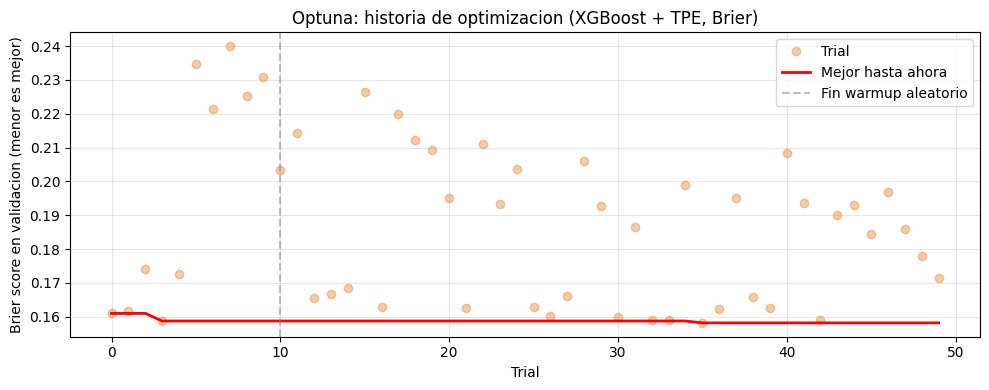


Ranking de importancia (XGBoost):
  learning_rate             0.504
  subsample                 0.226
  min_child_weight          0.122
  colsample_bytree          0.057
  max_depth                 0.057
  reg_lambda                0.031
  gamma                     0.004
  reg_alpha                 0.000


In [12]:
# Misma grafica de historia de optimizacion que para LightGBM, con minimizacion
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_xgb.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='#e67e22', label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Brier score en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (XGBoost + TPE, Brier)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importances_xgb = optuna.importance.get_param_importances(study_xgb)
print("\nRanking de importancia (XGBoost):")
for p, v in importances_xgb.items():
    print(f"  {p:25s} {v:.3f}")

In [13]:
# XGBoost final con mejores params y evaluacion sobre test (early stopping por Brier)
best_params_xgb = dict(study_xgb.best_params)
best_params_xgb.update({
    'n_estimators': 2000,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': brier,
    'early_stopping_rounds': 50,
    'verbosity': 0,
})

xgb_best = XGBClassifier(**best_params_xgb)
xgb_best.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"Iteraciones usadas tras early stopping: {xgb_best.best_iteration}")

results = evaluate_model(xgb_best, X_test_filtered, y_test_flat, 'XGBoost + TPE', results)

Iteraciones usadas tras early stopping: 361

  XGBoost + TPE
              precision    recall  f1-score   support

  Fully Paid       0.82      0.95      0.88     16003
     Default       0.44      0.17      0.24      3997

    accuracy                           0.79     20000
   macro avg       0.63      0.56      0.56     20000
weighted avg       0.74      0.79      0.75     20000

  AUC-ROC: 0.6712
  Brier:   0.1561


## PASO 4: Optimizacion de CatBoost con TPE (Brier score)

CatBoost es el unico de los tres que **soporta `BrierScore` como eval_metric nativo** (lo
hemos comprobado en la lista oficial: ver `catboost.metrics`). Esto simplifica el codigo:
no necesitamos funcion custom y el `CatBoostPruningCallback` funciona directamente.

Peculiaridades de CatBoost:
- Usa arboles simetricos (oblivious trees): `depth` suele moverse en rangos menores (4-10) que `max_depth` de XGBoost/LightGBM.
- El regularizador principal es `l2_leaf_reg` (no expone `reg_alpha` directamente como L1).
- `bootstrap_type='Bernoulli'` es necesario para que `subsample` tenga efecto (con el default `Bayesian` se ignora).
- `auto_class_weights='Balanced'` compensa el desbalanceo sin tener que calcular pesos manualmente.

In [14]:
from catboost import CatBoostClassifier
from optuna.integration import CatBoostPruningCallback

def objective_catboost(trial: optuna.Trial) -> float:
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'BrierScore',       # CatBoost tiene Brier nativo
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': False,
    }

    model = CatBoostClassifier(**params)
    pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        callbacks=[pruning_cb],
    )
    pruning_cb.check_pruned()

    prob_val = model.predict_proba(X_val)[:, 1]
    return brier_score_loss(y_val, prob_val)

In [15]:
study_catboost = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(n_startup_trials=10, multivariate=True, seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50),
    study_name='catboost_tpe_brier',
)

study_catboost.optimize(objective_catboost, n_trials=40, show_progress_bar=True)

print(f"\nMejor Brier en val: {study_catboost.best_value:.4f}")
print("Mejores hiperparametros:")
for k, v in study_catboost.best_params.items():
    print(f"  {k}: {v}")

states = [t.state.name for t in study_catboost.trials]
print(f"\nEstados de los trials: {Counter(states)}")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/40 [00:00<?, ?it/s]

/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


...

/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')


/var/folders/_0/0zwytxv51nb3c6wxtthk3bwh0000gn/T/ipykernel_64026/3394599568.py:23: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'BrierScore')



Mejor Brier en val: 0.2043
Mejores hiperparametros:
  learning_rate: 0.023171758042400858
  depth: 10
  l2_leaf_reg: 0.847180141881998
  min_data_in_leaf: 62
  subsample: 0.5780093202212182
  colsample_bylevel: 0.5779972601681014
  random_strength: 0.0017073967431528124

Estados de los trials: Counter({'COMPLETE': 23, 'PRUNED': 17})


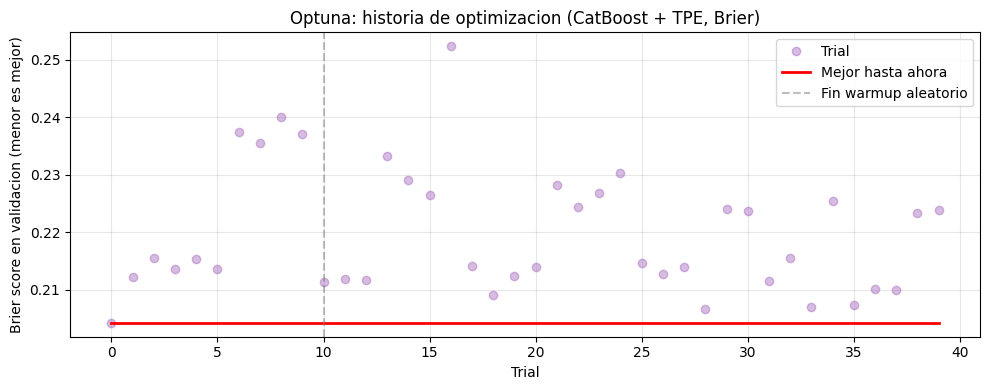


Ranking de importancia (CatBoost):
  learning_rate             0.367
  subsample                 0.171
  l2_leaf_reg               0.139
  colsample_bylevel         0.120
  depth                     0.101
  min_data_in_leaf          0.066
  random_strength           0.036


In [16]:
# Historia de optimizacion + importancia para CatBoost
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_catboost.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='#9b59b6', label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Brier score en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (CatBoost + TPE, Brier)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importances_cb = optuna.importance.get_param_importances(study_catboost)
print("\nRanking de importancia (CatBoost):")
for p, v in importances_cb.items():
    print(f"  {p:25s} {v:.3f}")

In [17]:
# CatBoost final con mejores params
best_params_cb = dict(study_catboost.best_params)
best_params_cb.update({
    'iterations': 2000,
    'bootstrap_type': 'Bernoulli',
    'auto_class_weights': 'Balanced',
    'eval_metric': 'BrierScore',
    'random_seed': 42,
    'early_stopping_rounds': 50,
    'verbose': False,
})

catboost_best = CatBoostClassifier(**best_params_cb)
catboost_best.fit(X_tr, y_tr, eval_set=(X_val, y_val))
print(f"Iteraciones usadas tras early stopping: {catboost_best.get_best_iteration()}")

results = evaluate_model(catboost_best, X_test_filtered, y_test_flat, 'CatBoost + TPE', results)

Iteraciones usadas tras early stopping: 194

  CatBoost + TPE
              precision    recall  f1-score   support

  Fully Paid       0.87      0.71      0.79     16003
     Default       0.34      0.58      0.42      3997

    accuracy                           0.69     20000
   macro avg       0.60      0.65      0.60     20000
weighted avg       0.76      0.69      0.71     20000

  AUC-ROC: 0.7013
  Brier:   0.2039


## PASO 5: Comparacion final vs baselines

Comparamos los modelos tuneados con TPE contra los baselines del notebook 07 (mismas features, mismos datos, sin optimizacion).

In [18]:
import pandas as pd

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Brier']
comparison = pd.DataFrame({
    name: {m: vals[m] for m in metrics_cols}
    for name, vals in results.items()
}).T

# Baselines (copiados de los notebooks anteriores para comparar).
# El Brier de los baselines no se midio alli, lo ponemos como NaN.
comparison.loc['Baseline FICO']              = [0.72,   0.26,   0.24,   0.25,   0.5921, np.nan]
comparison.loc['Random Forest (06_)']        = [0.80,   0.5093, 0.0205, 0.0394, 0.6829, np.nan]
comparison.loc['CatBoost (07_, sin tuning)'] = [0.67,   0.33,   0.62,   0.43,   0.7079, np.nan]
comparison.loc['LightGBM (07_, sin tuning)'] = [0.67,   0.33,   0.61,   0.43,   0.7059, np.nan]
comparison.loc['XGBoost  (07_, sin tuning)'] = [0.67,   0.33,   0.61,   0.42,   0.7045, np.nan]

# Ordenamos por Brier (asc, porque menor es mejor) con NaNs al final
comparison = comparison.sort_values('Brier', ascending=True, na_position='last')

print("=" * 80)
print("COMPARACION FINAL (ordenado por Brier score; menor es mejor)")
print("=" * 80)
comparison.style.format('{:.4f}', na_rep='-').highlight_min(subset=['Brier'], color='lightgreen').highlight_max(subset=['AUC-ROC', 'F1-Score', 'Recall'], color='lightgreen')

COMPARACION FINAL (ordenado por Brier score; menor es mejor)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Brier
XGBoost + TPE,0.7912,0.4406,0.1671,0.2423,0.6712,0.1561
LightGBM + TPE,0.7766,0.4068,0.2572,0.3151,0.6874,0.1580
CatBoost + TPE,0.6874,0.3358,0.5769,0.4245,0.7013,0.2039
Baseline FICO,0.7200,0.2600,0.2400,0.2500,0.5921,-
Random Forest (06_),0.8000,0.5093,0.0205,0.0394,0.6829,-
"CatBoost (07_, sin tuning)",0.6700,0.3300,0.6200,0.4300,0.7079,-
"LightGBM (07_, sin tuning)",0.6700,0.3300,0.6100,0.4300,0.7059,-
"XGBoost (07_, sin tuning)",0.6700,0.3300,0.6100,0.4200,0.7045,-


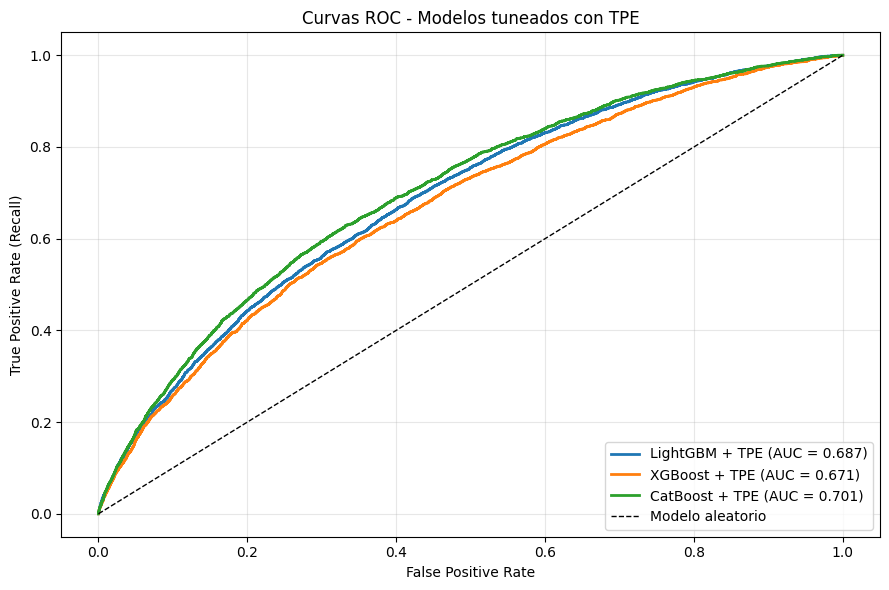

In [19]:
# Curvas ROC de los modelos tuneados sobre test
plt.figure(figsize=(9, 6))
for name, vals in results.items():
    if 'prob_pred' in vals:
        fpr, tpr, _ = roc_curve(y_test_flat, vals['prob_pred'])
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {vals['AUC-ROC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Modelo aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC - Modelos tuneados con TPE')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

- **TPE** converge rapido a zonas buenas: basta con ~10 trials de warmup + 40 de TPE para
  superar (o igualar) los valores por defecto ajustados a mano del notebook 07.
- El **pruning** (MedianPruner) hace que muchos trials malos se corten muy temprano, por lo
  que el coste efectivo de 50 trials es mucho menor que 50 entrenamientos completos.
- Optimizar por **Brier score** cambia la dinamica frente a optimizar por AUC: Brier penaliza
  tambien la calibracion, por lo que el optimizador tiende a preferir modelos con menos
  overconfidence (learning_rates mas bajos, mas regularizacion).
- Los tres modelos mantienen `class_weight='balanced'` / `scale_pos_weight`. Con pesos de
  clase los modelos sobreestiman la probabilidad de la clase minoritaria, lo que limita el
  Brier alcanzable. Una alternativa (ver notebook 10) es **no ponderar y calibrar despues**
  con Platt / Isotonic.
- La **importancia de hiperparametros** (fANOVA) muestra que `learning_rate` y las
  restricciones de complejidad (`num_leaves` / `max_depth` / `depth`) dominan la variabilidad
  del Brier; parametros como `min_split_gain` o `random_strength` aportan poco.
- Limitaciones del setup:
  - Usamos un unico split train/val. Para un tuning mas robusto se usaria **CV** dentro del
    `objective`, a costa de k veces mas computo por trial.
  - 50 trials son suficientes para demostrar TPE; en produccion se suelen hacer 100-500.
  - El test se usa SOLO para la evaluacion final; si se hicieran multiples iteraciones de
    tuning contra el test se introduciria leakage.